In [1]:
import pandas as pd

In [2]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")
perf = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

print(nav.columns)
print(benchmark.columns)
print(perf.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')
Index(['date', 'index_name', 'close_value'], dtype='str')
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


In [3]:
benchmark["index_name"].unique()


<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

# Daily Return Analysis

In [4]:
#Load NAV Data

import pandas as pd
import numpy as np

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
# Calculate Daily Returns

nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [6]:
#Verify Results

nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

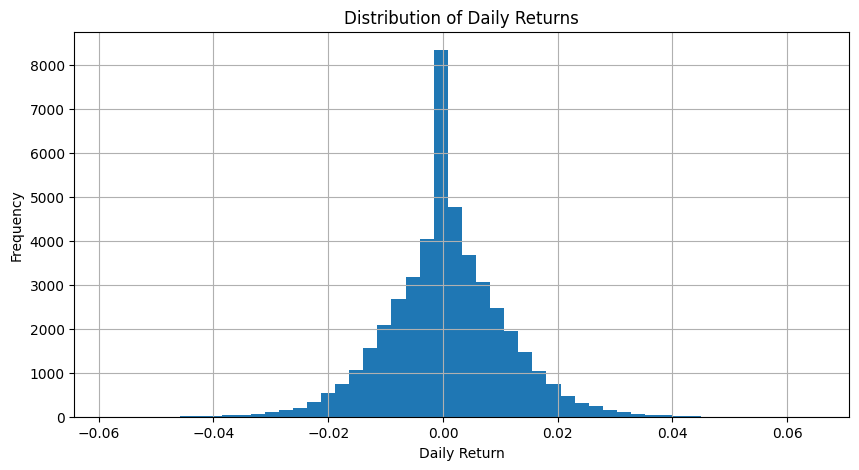

In [7]:
#Distribution Chart

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

nav["daily_return"].dropna().hist(
    bins=50
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [8]:
#Save Deliverable

nav.to_csv(
    "../data/processed/returns_computed.csv",
    index=False
)

print("returns_computed.csv created")

returns_computed.csv created


### Observation

- Daily returns are centered around zero, indicating normal day-to-day market fluctuations.
- Most returns fall within a narrow range, while extreme gains and losses occur less frequently.
- The return distribution resembles a bell-shaped pattern with occasional outliers.
- Daily return calculations form the foundation for risk and performance metrics such as CAGR, Sharpe Ratio, Sortino Ratio, Alpha, and Beta.

In [9]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

# CAGR Analysis

In [10]:
#Latest NAV

latest_date = nav["date"].max()

print(latest_date)

2026-05-29 00:00:00


In [11]:
#CAGR Function

def calculate_cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years) - 1) * 100

In [12]:
#Calculate CAGR for Every Fund

cagr_results = []

for fund in nav["amfi_code"].unique():

    fund_data = nav[nav["amfi_code"] == fund].sort_values("date")

    try:
        latest_nav = fund_data.iloc[-1]["nav"]

        nav_1yr = fund_data.iloc[-252]["nav"]
        nav_3yr = fund_data.iloc[-756]["nav"]
        nav_5yr = fund_data.iloc[0]["nav"]

        cagr_1yr = calculate_cagr(nav_1yr, latest_nav, 1)
        cagr_3yr = calculate_cagr(nav_3yr, latest_nav, 3)
        cagr_5yr = calculate_cagr(nav_5yr, latest_nav, 5)

        cagr_results.append([
            fund,
            cagr_1yr,
            cagr_3yr,
            cagr_5yr
        ])

    except:
        pass

In [13]:
#reate CAGR Table

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr_1yr",
        "cagr_3yr",
        "cagr_5yr"
    ]
)

cagr_df.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,-3.305509,-0.031628,2.316843
1,100025,2.501760,4.614329,3.912653
2,100033,47.734590,33.629211,26.074068
3,101206,45.093927,32.528591,20.442730
4,101207,-24.242050,-2.696475,6.953336


In [14]:
#Join Fund Names

fund = pd.read_csv("../data/raw/01_fund_master.csv")

cagr_df = cagr_df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

cagr_df.head()

,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr,scheme_name
0,100016,-3.305509,-0.031628,2.316843,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,2.501760,4.614329,3.912653,HDFC Short Term Debt Fund - Regular - Growth
2,100033,47.734590,33.629211,26.074068,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,45.093927,32.528591,20.442730,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-24.242050,-2.696475,6.953336,ABSL Small Cap Fund - Regular - Growth


In [15]:
#Top 10 Funds by 3-Year CAGR

top10 = cagr_df.sort_values(
    "cagr_3yr",
    ascending=False
).head(10)

top10[[
    "scheme_name",
    "cagr_3yr"
]]

,scheme_name,cagr_3yr
16,Axis Midcap Fund - Regular - Growth,36.066017
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,33.629211
3,ABSL Frontline Equity Fund - Regular - Growth,32.528591
34,Mirae Asset Large Cap Fund - Regular - Growth,31.278573
25,ICICI Pru Midcap Fund - Regular - Growth,30.206535
24,ICICI Pru Bluechip Fund - Direct - Growth,28.369809
21,SBI Small Cap Fund - Regular Plan - Growth,27.814418
19,SBI Bluechip Fund - Regular Plan - Growth,27.727428
8,UTI Flexi Cap Fund - Regular - Growth,25.663042
30,Kotak Flexicap Fund - Regular - Growth,25.661883


In [16]:
cagr_df.to_csv(
    "../data/processed/cagr_report.csv",
    index=False
)

print("cagr_report.csv created")

cagr_report.csv created


### Observation

- CAGR provides a standardized annual growth measure across different investment horizons.
- Several funds generated strong 3-year and 5-year annualized returns.
- Long-term CAGR values help identify consistently performing funds.
- CAGR rankings form a key input for the final fund scorecard.

In [17]:
top10[["scheme_name","cagr_3yr"]]

,scheme_name,cagr_3yr
16,Axis Midcap Fund - Regular - Growth,36.066017
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,33.629211
3,ABSL Frontline Equity Fund - Regular - Growth,32.528591
34,Mirae Asset Large Cap Fund - Regular - Growth,31.278573
25,ICICI Pru Midcap Fund - Regular - Growth,30.206535
24,ICICI Pru Bluechip Fund - Direct - Growth,28.369809
21,SBI Small Cap Fund - Regular Plan - Growth,27.814418
19,SBI Bluechip Fund - Regular Plan - Growth,27.727428
8,UTI Flexi Cap Fund - Regular - Growth,25.663042
30,Kotak Flexicap Fund - Regular - Growth,25.661883


# Sharpe Ratio Analysis

In [18]:
risk_free_rate = 0.065  # 6.5%

In [19]:
nav.columns

Index(['amfi_code', 'date', 'nav', 'daily_return'], dtype='str')

In [20]:
#Sharpe Ratios

risk_free_rate = 0.065

daily_rf = risk_free_rate / 252

sharpe_results = []

for fund in nav["amfi_code"].unique():

    fund_returns = (
        nav[nav["amfi_code"] == fund]["daily_return"]
        .dropna()
    )

    mean_return = fund_returns.mean()
    std_return = fund_returns.std()

    sharpe = (
        (mean_return - daily_rf)
        / std_return
    ) * np.sqrt(252)

    sharpe_results.append([
        fund,
        sharpe
    ])

In [21]:
#Create DataFrame

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [22]:
type(fund)

numpy.int64

In [23]:
print(fund)

149324


In [24]:
fund = pd.read_csv("../data/raw/01_fund_master.csv")

In [25]:
type(fund)

pandas.DataFrame

In [26]:
fund.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [27]:
sharpe_df = sharpe_df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [28]:
sharpe_df.head()

,amfi_code,sharpe_ratio,scheme_name
0,100016,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.567095,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.027213,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.162661,ABSL Small Cap Fund - Regular - Growth


In [29]:
sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)

sharpe_df.head(10)[
    ["scheme_name", "sharpe_ratio"]
]

,scheme_name,sharpe_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,1.448291
30,Kotak Flexicap Fund - Regular - Growth,1.306744
36,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930
19,SBI Bluechip Fund - Regular Plan - Growth,1.208267
25,ICICI Pru Midcap Fund - Regular - Growth,1.180101
38,DSP Midcap Fund - Regular - Growth,1.132122
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699
9,Nippon India Large Cap Fund - Regular - Growth,1.081659
3,ABSL Frontline Equity Fund - Regular - Growth,1.027213
24,ICICI Pru Bluechip Fund - Direct - Growth,1.026524


### Observation

- Mirae Asset Large Cap Fund achieved the highest Sharpe Ratio, indicating the strongest risk-adjusted performance.
- Large-cap and flexi-cap funds dominate the top rankings.
- Funds with Sharpe Ratios above 1 demonstrated strong returns relative to their volatility.
- Sharpe Ratio rankings provide a useful measure for comparing investment efficiency across funds.

# Sortino Ratio Analysis


In [30]:
risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

sortino_results = []

for fund_code in nav["amfi_code"].unique():

    returns = (
        nav[nav["amfi_code"] == fund_code]["daily_return"]
        .dropna()
    )

    mean_return = returns.mean()

    downside_returns = returns[returns < 0]

    downside_std = downside_returns.std()

    if downside_std != 0:

        sortino = (
            (mean_return - daily_rf)
            / downside_std
        ) * np.sqrt(252)

    else:
        sortino = np.nan

    sortino_results.append([
        fund_code,
        sortino
    ])

In [31]:
#Create DataFrame
sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.head()


,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [32]:
#Add Fund Names

sortino_df = sortino_df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

sortino_df.head()

,amfi_code,sortino_ratio,scheme_name
0,100016,-0.351047,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.941821,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.276644,ABSL Small Cap Fund - Regular - Growth


In [33]:
#Rank Funds

sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)

sortino_df.head(10)[
    ["scheme_name", "sortino_ratio"]
]

,scheme_name,sortino_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,2.385644
30,Kotak Flexicap Fund - Regular - Growth,2.364320
36,Mirae Asset Tax Saver Fund - Regular - Growth,2.146914
19,SBI Bluechip Fund - Regular Plan - Growth,2.140267
25,ICICI Pru Midcap Fund - Regular - Growth,2.029353
38,DSP Midcap Fund - Regular - Growth,1.875101
9,Nippon India Large Cap Fund - Regular - Growth,1.850133
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.829134
24,ICICI Pru Bluechip Fund - Direct - Growth,1.805294
3,ABSL Frontline Equity Fund - Regular - Growth,1.799563


In [34]:
sortino_df.to_csv(
    "../data/processed/sortino_values.csv",
    index=False
)

print("sortino_values.csv created")

sortino_values.csv created


### Observation

- Sortino Ratio focuses only on downside risk.
- Funds with high Sortino Ratios generated strong returns while limiting negative-return volatility.
- Sortino Ratio is often preferred over Sharpe Ratio when evaluating downside protection.
- Top-ranked funds demonstrated efficient risk-adjusted performance during adverse market conditions.

In [35]:
sortino_df.head(10)[["scheme_name","sortino_ratio"]]

,scheme_name,sortino_ratio
34,Mirae Asset Large Cap Fund - Regular - Growth,2.385644
30,Kotak Flexicap Fund - Regular - Growth,2.364320
36,Mirae Asset Tax Saver Fund - Regular - Growth,2.146914
19,SBI Bluechip Fund - Regular Plan - Growth,2.140267
25,ICICI Pru Midcap Fund - Regular - Growth,2.029353
38,DSP Midcap Fund - Regular - Growth,1.875101
9,Nippon India Large Cap Fund - Regular - Growth,1.850133
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.829134
24,ICICI Pru Bluechip Fund - Direct - Growth,1.805294
3,ABSL Frontline Equity Fund - Regular - Growth,1.799563


# Maximum Drawdown Analysis

In [36]:
mdd_results = []

for fund_code in nav["amfi_code"].unique():

    fund_nav = (
        nav[nav["amfi_code"] == fund_code]
        .sort_values("date")
        .copy()
    )

    fund_nav["running_max"] = fund_nav["nav"].cummax()

    fund_nav["drawdown"] = (
        fund_nav["nav"] / fund_nav["running_max"] - 1
    )

    max_drawdown = fund_nav["drawdown"].min()

    mdd_results.append([
        fund_code,
        max_drawdown
    ])

In [37]:
mdd_df = pd.DataFrame(
    mdd_results,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

mdd_df = mdd_df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

mdd_df.sort_values("max_drawdown").head(10)

,amfi_code,max_drawdown,scheme_name
22,119599,-0.525742,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.516778,Axis Small Cap Fund - Regular - Growth
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth
39,149324,-0.311719,DSP Small Cap Fund - Regular - Growth
21,119598,-0.287060,SBI Small Cap Fund - Regular Plan - Growth
7,102886,-0.280011,UTI Mid Cap Fund - Regular - Growth
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
29,120842,-0.240035,Kotak Emerging Equity Fund - Regular - Growth
11,118634,-0.233449,Nippon India Small Cap Fund - Regular - Growth
15,119093,-0.217514,Axis Bluechip Fund - Direct - Growth


In [38]:
mdd_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

### Observation

- Maximum Drawdown measures the largest peak-to-trough decline experienced by a fund.
- Funds with smaller drawdowns demonstrated stronger downside protection.
- Large drawdowns indicate periods of significant capital erosion during market stress.
- Maximum Drawdown is an important risk metric and will be used in the final fund scorecard.

In [39]:
mdd_df.sort_values("max_drawdown").head(10)[
    ["scheme_name", "max_drawdown"]
]

,scheme_name,max_drawdown
22,SBI Small Cap Fund - Direct Plan - Growth,-0.525742
17,Axis Small Cap Fund - Regular - Growth,-0.516778
4,ABSL Small Cap Fund - Regular - Growth,-0.354469
39,DSP Small Cap Fund - Regular - Growth,-0.311719
21,SBI Small Cap Fund - Regular Plan - Growth,-0.287060
7,UTI Mid Cap Fund - Regular - Growth,-0.280011
0,HDFC Top 100 Fund - Regular Plan - Growth,-0.247344
29,Kotak Emerging Equity Fund - Regular - Growth,-0.240035
11,Nippon India Small Cap Fund - Regular - Growth,-0.233449
15,Axis Bluechip Fund - Direct - Growth,-0.217514


In [40]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [41]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

# Alpha and Beta Analysis

In [42]:
#NIFTY100 Benchmark

benchmark["date"] = pd.to_datetime(benchmark["date"])

nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [43]:
#Import Regression Function


from scipy.stats import linregress

In [44]:
#Calculate Alpha & Beta

alpha_beta_results = []

for fund_code in nav["amfi_code"].unique():

    fund_returns = nav[
        nav["amfi_code"] == fund_code
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund_returns,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) > 30:

        slope, intercept, r_value, p_value, std_err = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        beta = slope
        alpha = intercept * 252

        alpha_beta_results.append([
            fund_code,
            alpha,
            beta
        ])

In [45]:
#Create DataFrame

alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [46]:
#Add Fund Names

alpha_beta_df = alpha_beta_df.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

alpha_beta_df.head()

,amfi_code,alpha,beta,scheme_name
0,100016,0.037476,-0.058268,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,ABSL Small Cap Fund - Regular - Growth


In [47]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv created")

alpha_beta.csv created


In [48]:
alpha_beta_df.sort_values(
    "alpha",
    ascending=False
).head(10)[
    ["scheme_name", "alpha", "beta"]
]

,scheme_name,alpha,beta
21,SBI Small Cap Fund - Regular Plan - Growth,0.303370,-0.023196
39,DSP Small Cap Fund - Regular - Growth,0.300579,0.011455
25,ICICI Pru Midcap Fund - Regular - Growth,0.292636,0.000549
36,Mirae Asset Tax Saver Fund - Regular - Growth,0.282704,0.018134
30,Kotak Flexicap Fund - Regular - Growth,0.273305,-0.022830
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104
34,Mirae Asset Large Cap Fund - Regular - Growth,0.269838,0.023684
38,DSP Midcap Fund - Regular - Growth,0.265986,-0.002523
16,Axis Midcap Fund - Regular - Growth,0.260767,-0.066265
19,SBI Bluechip Fund - Regular Plan - Growth,0.232010,-0.031751


### Observation

- Alpha measures excess return generated beyond benchmark expectations.
- Positive Alpha indicates fund managers added value beyond market movements.
- Beta measures sensitivity to benchmark fluctuations.
- Funds with high Alpha and moderate Beta provide attractive risk-adjusted performance.

In [49]:
alpha_beta_df.sort_values(
    "alpha",
    ascending=False
).head(10)[
    ["scheme_name","alpha","beta"]
]

,scheme_name,alpha,beta
21,SBI Small Cap Fund - Regular Plan - Growth,0.303370,-0.023196
39,DSP Small Cap Fund - Regular - Growth,0.300579,0.011455
25,ICICI Pru Midcap Fund - Regular - Growth,0.292636,0.000549
36,Mirae Asset Tax Saver Fund - Regular - Growth,0.282704,0.018134
30,Kotak Flexicap Fund - Regular - Growth,0.273305,-0.022830
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.271954,0.005104
34,Mirae Asset Large Cap Fund - Regular - Growth,0.269838,0.023684
38,DSP Midcap Fund - Regular - Growth,0.265986,-0.002523
16,Axis Midcap Fund - Regular - Growth,0.260767,-0.066265
19,SBI Bluechip Fund - Regular Plan - Growth,0.232010,-0.031751


In [50]:
perf.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

# Fund Scorecard

In [51]:
#Prepare Ranking Data

scorecard = perf.copy()

scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(
    ascending=False,
    pct=True
)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(
    ascending=False,
    pct=True
)

scorecard["alpha_rank"] = scorecard["alpha"].rank(
    ascending=False,
    pct=True
)

scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(
    ascending=True,
    pct=True
)

scorecard["drawdown_rank"] = scorecard["max_drawdown_pct"].rank(
    ascending=False,
    pct=True
)

In [52]:
#Calculate Composite Score

scorecard["fund_score"] = (
    scorecard["return_rank"] * 30 +
    scorecard["sharpe_rank"] * 25 +
    scorecard["alpha_rank"] * 20 +
    scorecard["expense_rank"] * 15 +
    scorecard["drawdown_rank"] * 10
)

In [53]:
scorecard["fund_score"] = (
    scorecard["fund_score"] /
    scorecard["fund_score"].max()
) * 100

In [54]:
top_funds = scorecard.sort_values(
    "fund_score",
    ascending=False
)

top_funds[[
    "scheme_name",
    "fund_score"
]].head(10)

,scheme_name,fund_score
36,Mirae Asset Tax Saver Fund - Regular - Growth,100.000000
10,ICICI Pru Bluechip Fund - Regular - Growth,98.070988
24,Axis Bluechip Fund - Regular - Growth,92.206790
0,SBI Bluechip Fund - Regular Plan - Growth,85.030864
31,UTI Nifty 50 Index Fund - Regular - Growth,83.873457
20,Kotak Bluechip Fund - Regular - Growth,81.790123
17,Nippon India Small Cap Fund - Regular - Growth,77.314815
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,76.003086
1,SBI Bluechip Fund - Direct Plan - Growth,75.231481
39,DSP Small Cap Fund - Regular - Growth,74.074074


In [55]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv created")

fund_scorecard.csv created


### Observation

- The fund scorecard combines return, risk-adjusted performance, alpha generation, expense efficiency, and downside protection.
- Higher scores indicate stronger overall performance across multiple dimensions.
- The composite score provides a simple ranking framework for comparing mutual funds.
- Top-ranked funds consistently performed well across return and risk metrics.

In [56]:
top_funds[["scheme_name","fund_score"]].head(10)

,scheme_name,fund_score
36,Mirae Asset Tax Saver Fund - Regular - Growth,100.000000
10,ICICI Pru Bluechip Fund - Regular - Growth,98.070988
24,Axis Bluechip Fund - Regular - Growth,92.206790
0,SBI Bluechip Fund - Regular Plan - Growth,85.030864
31,UTI Nifty 50 Index Fund - Regular - Growth,83.873457
20,Kotak Bluechip Fund - Regular - Growth,81.790123
17,Nippon India Small Cap Fund - Regular - Growth,77.314815
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,76.003086
1,SBI Bluechip Fund - Direct Plan - Growth,75.231481
39,DSP Small Cap Fund - Regular - Growth,74.074074


# Benchmark Comparison


In [57]:
top5_codes = top_funds.head(5)["amfi_code"].tolist()

top5_codes

[148569, 120503, 119092, 119551, 102885]

In [58]:
top5_nav = nav[
    nav["amfi_code"].isin(top5_codes)
].copy()

top5_nav = top5_nav.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [59]:
bench_plot = benchmark[
    benchmark["index_name"].isin(
        ["NIFTY50", "NIFTY100"]
    )
].copy()

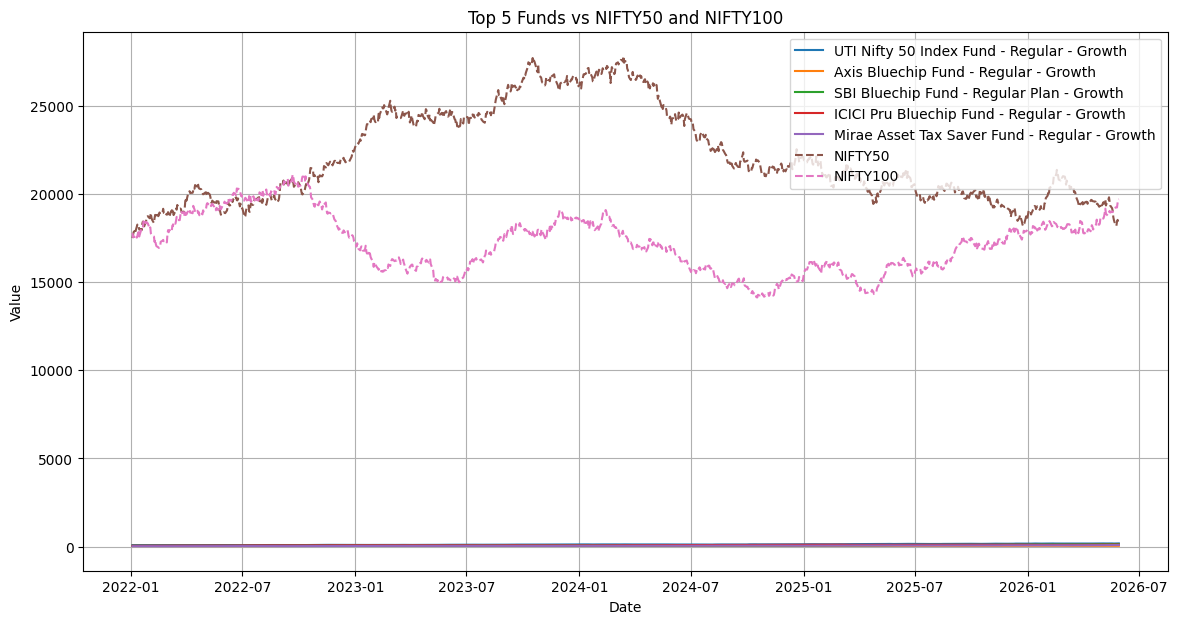

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

for scheme in top5_nav["scheme_name"].unique():

    temp = top5_nav[
        top5_nav["scheme_name"] == scheme
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=scheme
    )

for idx in ["NIFTY50", "NIFTY100"]:

    temp = bench_plot[
        bench_plot["index_name"] == idx
    ]

    plt.plot(
        temp["date"],
        temp["close_value"],
        linestyle="--",
        label=idx
    )

plt.title("Top 5 Funds vs NIFTY50 and NIFTY100")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.show()

In [61]:
plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [62]:
from numpy import sqrt

fund_code = top5_codes[0]

fund_ret = nav[
    nav["amfi_code"] == fund_code
][["date", "daily_return"]]

bench_ret = nifty100[
    ["date", "benchmark_return"]
]

tracking = pd.merge(
    fund_ret,
    bench_ret,
    on="date"
).dropna()

tracking_error = (
    (tracking["daily_return"] -
     tracking["benchmark_return"]).std()
) * sqrt(252)

print("Tracking Error:", tracking_error)

Tracking Error: 0.21736518889258571
